# 05 — DOMINANT vs GAD-NR: Grafo de Miembros (M)

Este notebook entrena y compara dos detectores de anomalías sobre el grafo de miembros `M`
usando la librería **PyGOD 1.1.0**:

- **DOMINANT** (Ding et al., SDM 2019): línea base consolidada en la literatura — encoder GCN
  compartido con dos decoders que reconstruyen estructura y atributos por separado.
- **GAD-NR** (Roy et al., WSDM 2024): estado del arte en la familia GNN+AE — reconstruye el
  vecindario completo de cada nodo (features propias, grado y distribución de atributos de vecinos).

## ¿Por qué este par de modelos?

Ambos pertenecen a la misma familia arquitectónica (GNN + Autoencoder, no supervisado) y
operan sobre el mismo objeto `Data` de PyG, lo que hace la comparativa limpia y directa.
La diferencia fundamental está en **qué reconstruyen**:

| Modelo | Reconstruye | Detecta bien |
|--------|------------|---------------|
| DOMINANT | Adyacencia $\hat{A}$ + features $\hat{X}$ | Anomalías estructurales y de atributos por separado |
| GAD-NR | Vecindario completo (features, grado, distribución de vecinos) | Anomalías contextuales, estructurales y joint-type |

## Diseño del consenso

DOMINANT expone **dos scores separados** por nodo:
- `dom_struct`: MSE entre adyacencia real $A$ y reconstruida $\hat{A}$
- `dom_attr`: MSE entre features reales $X$ y reconstruidas $\hat{X}$

GAD-NR expone un **score compuesto** que integra tres pérdidas ponderadas:
- error de reconstrucción de features propias (`feature_loss_per_node`)
- error de reconstrucción de grado (`degree_loss_per_node`)
- divergencia KL de la distribución de vecinos (`h_loss_per_node`)

El **score de consenso final** es la media de los percentiles de las 3 señales disponibles
(2 de DOMINANT + 1 de GAD-NR):

$$s^{consensus}_i = \frac{1}{3}\left(
    \text{pct}(s^{struct}_{DOM}) +
    \text{pct}(s^{attr}_{DOM}) +
    \text{pct}(s^{combined}_{GADNR})
\right)$$

Usar percentiles garantiza que cada señal contribuye por igual independientemente de su escala.

## Esquema del notebook

| Sección | Contenido |
|---------|-----------|
| 0 | Imports y configuración |
| 1 | Carga del grafo M |
| 2 | Fundamento teórico: DOMINANT y GAD-NR |
| 3 | Entrenamiento de DOMINANT |
| 4 | Entrenamiento de GAD-NR |
| 5 | Consenso final y tipología de anomalías |
| 6 | Spotlight — candidatos del EDA |
| 7 | Comparativa DOMINANT vs GAD-NR |
| 8 | Guardado de resultados |

## 0. Imports y configuración

In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from pygod.detector import DOMINANT, GADNR
from scipy.stats import rankdata, spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sys.path.insert(0, '..')
from src.utils.visualization import (
    apply_theme, polish, save_figure,
    PALETTE, CAT_COLORS, CMAP_SEQ, CMAP_HEAT,
    FS, FONT,
)
apply_theme()

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
GRAPH_DATA_PATH = '../data/graph_data/'
PROCESSED_PATH  = '../data/processed/'
RESULTS_PATH    = '../data/results/'
os.makedirs(RESULTS_PATH, exist_ok=True)

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_idx = 0 if torch.cuda.is_available() else -1
print(f'Device : {device}')
print(f'PyGOD  : DOMINANT y GADNR importados correctamente')

c:\Users\marco\.conda\envs\TFM_grafos_V2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
PyGOD  : DOMINANT y GADNR importados correctamente


## 1. Carga del grafo M

Cargamos el objeto `Data` del grafo M generado en el notebook `04_feature_engineering.ipynb`.
Tanto DOMINANT como GAD-NR usan el grafo completo durante el entrenamiento — no hacen split
de aristas porque son modelos de detección de anomalías no supervisados, no de predicción de
enlaces. Necesitan ver toda la estructura para aprender el patrón normal.

PyGOD requiere un objeto `Data` con solo `x` y `edge_index` — los atributos adicionales
como `member_ids` o `edge_weight` deben eliminarse para evitar errores de conversión.

In [2]:
data_M = torch.load(os.path.join(GRAPH_DATA_PATH, 'data_M.pt'), weights_only=False)
print(data_M)
print(f'\nNodos          : {data_M.num_nodes}')
print(f'Aristas únicas : {data_M.num_edges // 2}')
print(f'Features/nodo  : {data_M.num_node_features}')

# Guardamos los IDs originales antes de limpiar el objeto Data
member_ids = data_M.member_ids  # lista de member_id en el mismo orden que los nodos

# Objeto limpio para PyGOD — solo x y edge_index
data_M_clean = Data(
    x=data_M.x,
    edge_index=data_M.edge_index,
)
print(f'\ndata_M_clean: {data_M_clean}')

Data(x=[11371, 3], edge_index=[2, 2352048], edge_weight=[2352048], member_ids=[11371])

Nodos          : 11371
Aristas únicas : 1176024
Features/nodo  : 3

data_M_clean: Data(x=[11371, 3], edge_index=[2, 2352048])


In [3]:
# Metadatos de miembros para interpretar resultados
meta_members = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-members.csv'))

# DataFrame base indexado por member_id — se enriquecerá con los scores
id_to_idx = {mid: i for i, mid in enumerate(member_ids)}
base_df = pd.DataFrame({'member_id': member_ids})
base_df['idx'] = base_df.index
base_df = base_df.merge(
    meta_members[['member_id', 'name', 'city', 'state']],
    on='member_id', how='left'
)

# Grado de cada nodo (aristas únicas / 2 porque el grafo es no dirigido y duplicado)
edge_src = data_M.edge_index[0].numpy()
degree = np.bincount(edge_src, minlength=data_M.num_nodes) // 2  # cada arista aparece dos veces
base_df['degree'] = degree

print(f'base_df: {base_df.shape}')
base_df.head()

base_df: (11371, 6)


,member_id,idx,name,city,state,degree
0,2069,0,Wesley Duffee-Braun,Brentwood,TN,219
1,8386,1,Tim,Nashville,TN,307
2,9205,2,Brenda,Brentwood,TN,334
3,42506,3,Chris Meador,Nashville,TN,122
4,106758,4,Kt,Antioch,TN,119


## 2. Fundamento teórico: DOMINANT y GAD-NR

### 2.1 DOMINANT (Ding et al., SDM 2019)

DOMINANT extiende el GAE estándar con un segundo decoder. Tiene tres componentes:

**Encoder GCN compartido.** Produce embeddings latentes $Z$ combinando features $X$ y estructura $A$:
$$Z = \text{GCN}(X, A)$$

**Decoder de estructura.** Producto interno con sigmoide — idéntico al GAE clásico:
$$\hat{A}_{ij} = \sigma(z_i^T z_j)$$

**Decoder de atributos.** Una GCN que reconstruye la matriz de features original desde los embeddings:
$$\hat{X} = \text{GCN}(Z, A)$$

La función de pérdida combina los dos errores de reconstrucción ponderados por `weight` $\in [0, 1]$:
$$\mathcal{L} = (1 - w) \cdot \|A - \hat{A}\|_F^2 + w \cdot \|X - \hat{X}\|_F^2$$

El anomaly score de cada nodo se calcula de forma análoga:
$$s_i = (1 - w) \cdot s_i^{struct} + w \cdot s_i^{attr}$$

En este notebook tratamos $s_i^{struct}$ y $s_i^{attr}$ como **señales independientes**
para mantener la distinción entre anomalía estructural y de atributo.

### 2.2 GAD-NR (Roy et al., WSDM 2024)

GAD-NR parte de la limitación clave de DOMINANT y los GAE clásicos: al reconstruir solo
los enlaces directos, los nodos conectados se agrupan en el espacio latente, lo que hace
que el modelo sea bueno detectando anomalías de tipo cluster pero no anomalías más complejas.

La solución es reconstruir el **vecindario completo** de cada nodo, capturando tres dimensiones:

**Reconstrucción de features propias.** Error entre las features reales del nodo y su reconstrucción:
$$\mathcal{L}_{feat} = \|x_i - \hat{x}_i\|^2$$

**Reconstrucción de grado.** Error entre el grado real y el grado predicho por un decoder MLP:
$$\mathcal{L}_{deg} = \text{CrossEntropy}(d_i, \hat{d}_i)$$

**Reconstrucción de la distribución de vecinos.** Divergencia KL entre la distribución real
de features de los vecinos y la distribución reconstruida (modelada como Gaussiana):
$$\mathcal{L}_{neigh} = D_{KL}(p_{neigh}(x) \| q_{neigh}(z))$$

La pérdida total combina las tres con pesos `lambda_loss1` (vecindario), `lambda_loss2` (features)
y `lambda_loss3` (grado). El anomaly score final es la combinación ponderada de las tres pérdidas
por nodo.

### 2.3 Hiperparámetros para el grafo M

| Hiperparámetro | DOMINANT | GAD-NR | Justificación |
|---|---|---|---|
| `hid_dim` | 64 | 64 | Dimensión latente estándar |
| `num_layers` | 4 | 1 | DOMINANT: 2 enc + 2 dec. GAD-NR: encoder ligero, decoders MLP |
| `dropout` | 0.0 | 0.0 | Grafo grande, sin riesgo significativo de sobreajuste |
| `weight` / — | 0.2 | — | DOMINANT: más peso a estructura (0.8) que a atributos (0.2), justificado porque M solo tiene 3 features geográficas frente a >1M aristas |
| `lambda_loss1/2/3` | — | 0.01/0.1/0.8 | GAD-NR: defaults del paper — más peso al grado que al vecindario |
| `epoch` | 200 | 200 | Convergencia suficiente para ambos modelos |
| `lr` | 0.004 | 0.01 | Defaults de PyGOD para cada modelo |
| `contamination` | 0.05 | 0.05 | P95 como umbral — 5% de anomalías esperadas |
| `batch_size` | 0 | 0 | Full batch — 11.371 nodos es manejable |
| `save_emb` | True | True | Guardar embeddings para análisis posterior |

## 3. Entrenamiento de DOMINANT

PyGOD usa una API similar a scikit-learn: se instancia el detector con los hiperparámetros
y se llama a `fit(data)`. Los scores quedan en `detector.decision_score_` y las etiquetas
binarias en `detector.label_` (determinadas por `contamination`).

Para acceder a los scores de estructura y atributo por separado — que usamos en el consenso —
realizamos un forward pass manual con el modelo interno `detector.model` tras el entrenamiento.

In [4]:
dominant = DOMINANT(
    hid_dim=64,
    num_layers=4,       # 2 capas encoder + 2 capas decoder
    dropout=0.0,
    weight_decay=0.0,
    act=F.relu,
    sigmoid_s=False,
    weight=0.2,         # peso del error de atributo: bajo porque M tiene solo 3 features
    contamination=0.05, # P95 — 5% de anomalías
    lr=0.004,
    epoch=200,
    gpu=gpu_idx,
    batch_size=0,       # full batch
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando DOMINANT sobre el grafo M...')
dominant.fit(data_M_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {dominant.decision_score_.shape}')
print(f'  min={dominant.decision_score_.min():.4f}, '
      f'max={dominant.decision_score_.max():.4f}, '
      f'mean={dominant.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {dominant.label_.sum().item()} '
      f'({dominant.label_.float().mean().item():.1%})')

Entrenando DOMINANT sobre el grafo M...
Epoch 0000: Loss 10.4131 |  | Time 1.04
Epoch 0001: Loss 10.3505 |  | Time 0.39
Epoch 0002: Loss 10.3175 |  | Time 0.31
Epoch 0003: Loss 10.3266 |  | Time 0.27
Epoch 0004: Loss 10.3100 |  | Time 0.29
Epoch 0005: Loss 10.3069 |  | Time 0.26
Epoch 0006: Loss 10.2925 |  | Time 0.29
Epoch 0007: Loss 10.2915 |  | Time 0.29
Epoch 0008: Loss 10.2700 |  | Time 0.26
Epoch 0009: Loss 10.2588 |  | Time 0.28
Epoch 0010: Loss 10.2523 |  | Time 0.27
Epoch 0011: Loss 10.2477 |  | Time 0.27
Epoch 0012: Loss 10.2322 |  | Time 0.28
Epoch 0013: Loss 10.2183 |  | Time 0.28
Epoch 0014: Loss 10.2056 |  | Time 0.28
Epoch 0015: Loss 10.1993 |  | Time 0.28
Epoch 0016: Loss 10.1893 |  | Time 0.27
Epoch 0017: Loss 10.1825 |  | Time 0.28
Epoch 0018: Loss 10.1741 |  | Time 0.28
Epoch 0019: Loss 10.1654 |  | Time 0.27
Epoch 0020: Loss 10.1589 |  | Time 0.27
Epoch 0021: Loss 10.1489 |  | Time 0.26
Epoch 0022: Loss 10.1460 |  | Time 0.30
Epoch 0023: Loss 10.1414 |  | Time 0.28


In [5]:
@torch.no_grad()
def get_dominant_subscores(detector, data):
    """
    Extrae los scores de estructura y atributo por separado desde DOMINANT.

    DOMINANTBase.forward() devuelve (x_hat, s_hat) donde:
      x_hat : features reconstruidas [N, in_dim]
      s_hat : adyacencia reconstruida densa [N, N]  (generada por process_graph)

    Returns
    -------
    struct_scores : np.ndarray [N]  — MSE por fila de A
    attr_scores   : np.ndarray [N]  — MSE por nodo en features
    """
    model = detector.model
    model.eval()

    # process_graph añade la adyacencia densa data.s al objeto Data
    data_proc = data.clone()
    model.process_graph(data_proc)

    x          = data_proc.x.to(device)
    edge_index = data_proc.edge_index.to(device)
    s_real     = data_proc.s.to(device)  # adyacencia densa real [N, N]

    # Forward: devuelve (x_hat, s_hat)
    x_hat, s_hat = model(x, edge_index)

    # Error de atributo por nodo: MSE entre X real y X reconstruida
    attr_scores   = ((x - x_hat) ** 2).mean(dim=1).cpu().numpy()

    # Error de estructura por nodo: MSE entre fila real y fila reconstruida de A
    struct_scores = ((s_real - s_hat) ** 2).mean(dim=1).cpu().numpy()

    return struct_scores, attr_scores


dom_struct, dom_attr = get_dominant_subscores(dominant, data_M_clean)

print(f'DOM struct — min={dom_struct.min():.6f}, max={dom_struct.max():.6f}, mean={dom_struct.mean():.6f}')
print(f'DOM attr   — min={dom_attr.min():.6f},  max={dom_attr.max():.6f},  mean={dom_attr.mean():.6f}')

# Verificación: el score combinado debe coincidir con (1-weight)*struct + weight*attr
score_check = (1 - dominant.weight) * dom_struct + dominant.weight * dom_attr
corr_check  = np.corrcoef(score_check, dominant.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación fórmula combinada — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')

DOM struct — min=0.000278, max=0.134699, mean=0.015152
DOM attr   — min=0.000000,  max=606.936768,  mean=0.912557

Verificación fórmula combinada — correlación con decision_score_: 0.039892
(debería ser ~1.0)


In [18]:
@torch.no_grad()
def get_dominant_subscores(detector, data):
    """
    Extrae los scores de estructura y atributo de DOMINANT.
    
    double_recon_loss calcula:
      attr_error   = sqrt(sum((x - x_)^2, dim=1))
      struct_error = sqrt(sum((s - s_)^2, dim=1))
      score = weight * attr_error + (1 - weight) * struct_error
    """
    model = detector.model
    model.eval()

    data_proc = data.clone()
    model.process_graph(data_proc)  # añade data_proc.s (adyacencia densa)

    x          = data_proc.x.to(device)
    edge_index = data_proc.edge_index.to(device)
    s_real     = data_proc.s.to(device)

    x_hat, s_hat = model(x, edge_index)

    # RMSE por nodo — igual que double_recon_loss
    attr_scores   = torch.sqrt(torch.sum((x - x_hat) ** 2, dim=1)).cpu().numpy()
    struct_scores = torch.sqrt(torch.sum((s_real - s_hat) ** 2, dim=1)).cpu().numpy()

    return struct_scores, attr_scores


dom_struct, dom_attr = get_dominant_subscores(dominant, data_M_clean)

print(f'DOM struct — min={dom_struct.min():.4f}, max={dom_struct.max():.4f}, mean={dom_struct.mean():.4f}')
print(f'DOM attr   — min={dom_attr.min():.4f},  max={dom_attr.max():.4f},  mean={dom_attr.mean():.4f}')

# Verificación: score = weight*attr + (1-weight)*struct
score_check = dominant.weight * dom_attr + (1 - dominant.weight) * dom_struct
corr_check  = np.corrcoef(score_check, dominant.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')

DOM struct — min=2.4480, max=41.6916, mean=12.8833
DOM attr   — min=0.0038,  max=2.1455,  mean=0.6923

Verificación — correlación con decision_score_: 0.972910
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_dominant_score_distributions_M.png


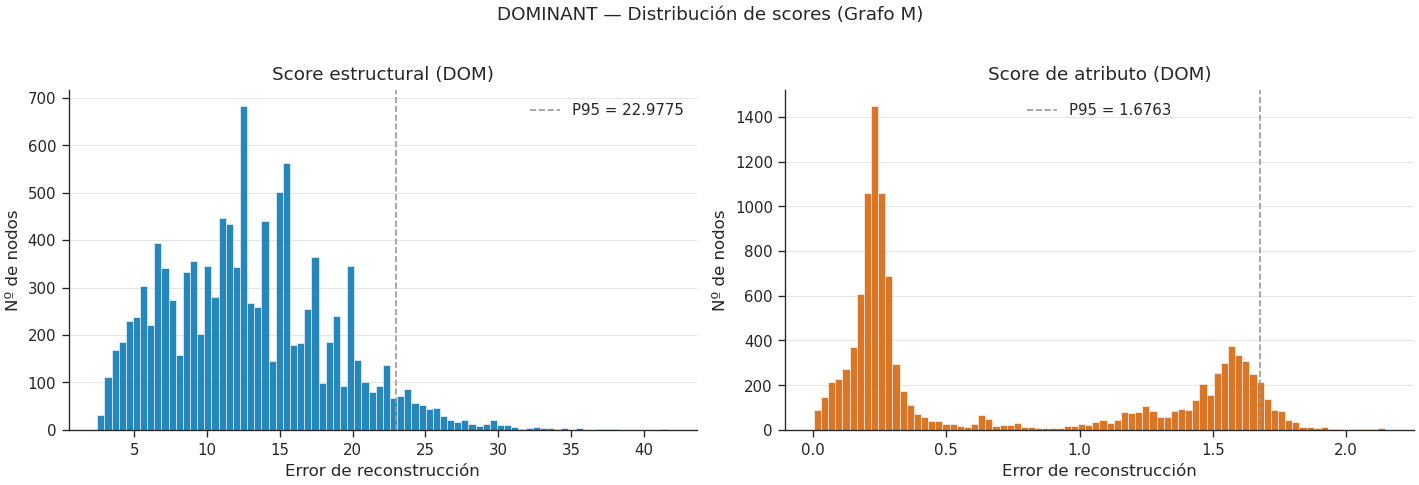

Correlación Spearman struct vs attr (DOMINANT): ρ = -0.1727


In [19]:
# Distribuciones de los dos scores de DOMINANT
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

for ax, scores, label, color in zip(
    axes,
    [dom_struct, dom_attr],
    ['Score estructural (DOM)', 'Score de atributo (DOM)'],
    [PALETTE['M'], PALETTE['anomaly']]
):
    ax.hist(scores, bins=80, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color=PALETTE['neutral'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.4f}')
    ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(label, fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.suptitle('DOMINANT — Distribución de scores (Grafo M)', fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '05_dominant_score_distributions_M.png')
plt.show()

rho_dom, _ = spearmanr(dom_struct, dom_attr)
print(f'Correlación Spearman struct vs attr (DOMINANT): ρ = {rho_dom:.4f}')

## 4. Entrenamiento de GAD-NR

GAD-NR tiene una arquitectura más compleja que DOMINANT. El encoder combina un MLP de
reducción de dimensionalidad seguido de un GNN de paso de mensajes. El decoder tiene tres
cabezas independientes: un MLP para las features propias, un MLP para el grado, y una
distribución Gaussiana para los atributos de los vecinos.

**Nota sobre `num_layers=1`:** en GAD-NR este parámetro controla el número de capas del
*encoder GNN*, no del modelo completo. El paper original usa 1 capa de encoder — añadir
más capas aumenta el over-smoothing y degrada la detección. Los decoders tienen sus propios
parámetros (`deg_dec_layers=4`, `fea_dec_layers=3`).

**Nota sobre `lambda_loss`:** los valores por defecto del paper son los que usa PyGOD:
`lambda_loss1=0.01` (vecindario), `lambda_loss2=0.1` (features), `lambda_loss3=0.8` (grado).
El grado recibe el mayor peso porque es la señal más robusta para detectar nodos con
patrones de conectividad anómalos.

In [9]:
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase
import pygod.detector.gadnr as _gadnr_module
# ── Workaround bug PyGOD 1.1.0 ──────────────────────────────────────────────
# tot_nodes se pasa al backbone GCN a través de **kwargs, pero GCNConv
# (PyG >= 2.5) ya no acepta ese argumento en MessagePassing.__init__().
# Parche: sobreescribimos init_model para filtrar tot_nodes antes del forward.
def _patched_init_model(self, **kwargs):
    kwargs.pop('tot_nodes', None)   # eliminar el argumento problemático
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,
    ).to(self.device)

GADNR.init_model = _patched_init_model
# ────────────────────────────────────────────────────────────────────────────


In [13]:
import torch
import torch.nn.functional as F
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase

# ── Workaround doble bug PyGOD 1.1.0 con GAD-NR en GPU ──────────────────────
# Bug 1: tot_nodes se pasa al backbone GCN que no lo acepta
# Bug 2: GADNRBase recibe device como string desde self.device pero algunos
#        tensores internos (neighbor_num_list en loss_func) se quedan en CPU
def _patched_init_model(self, **kwargs):
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,  # ya está en self.device
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,         # device correcto — cuda:0
    ).to(self.device)

def _patched_forward_model(self, data):
    # Aseguramos que todos los tensores de entrada están en el device correcto
    data.x = data.x.to(self.device)
    data.edge_index = data.edge_index.to(self.device)
    self.neighbor_num_list = self.neighbor_num_list.to(self.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        self.model(data.x, data.edge_index)

    loss, loss_per_node, h_loss, degree_loss, feature_loss = \
        self.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, self.neighbor_num_list
        )

    return (loss,
            loss_per_node.cpu().detach(),
            h_loss.cpu().detach(),
            degree_loss.cpu().detach(),
            feature_loss.cpu().detach())

GADNR.init_model    = _patched_init_model
GADNR.forward_model = _patched_forward_model

In [14]:
gadnr = GADNR(
    hid_dim=64,
    num_layers=1,           # capas del encoder GNN — 1 según el paper original
    deg_dec_layers=4,       # capas del decoder de grado
    fea_dec_layers=3,       # capas del decoder de features
    sample_size=2,          # muestras para la distribución de vecinos
    sample_time=3,          # repeticiones de muestreo para reducir ruido
    neigh_loss='KL',        # KL divergence para la distribución de vecinos
    lambda_loss1=0.01,      # peso del loss de vecindario
    lambda_loss2=0.1,       # peso del loss de features
    lambda_loss3=0.8,       # peso del loss de grado
    real_loss=True,
    contamination=0.05,     # P95 — consistente con DOMINANT
    lr=0.0005,
    epoch=200,
    dropout=0.0,
    weight_decay=0.0003,
    act=F.relu,
    gpu=gpu_idx,
    batch_size=0,           # full batch
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando GAD-NR sobre el grafo M...')
gadnr.fit(data_M_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {gadnr.decision_score_.shape}')
print(f'  min={gadnr.decision_score_.min():.4f}, '
      f'max={gadnr.decision_score_.max():.4f}, '
      f'mean={gadnr.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {gadnr.label_.sum().item()} '
      f'({gadnr.label_.float().mean().item():.1%})')

Entrenando GAD-NR sobre el grafo M...
Epoch 0001: Loss 67394.8047 |  | Time 1.24
Epoch 0002: Loss 67356.4219 |  | Time 0.71
Epoch 0003: Loss 67316.9609 |  | Time 0.71
Epoch 0004: Loss 67277.2266 |  | Time 0.71
Epoch 0005: Loss 67241.0625 |  | Time 0.71
Epoch 0006: Loss 67201.1484 |  | Time 0.72
Epoch 0007: Loss 67157.3359 |  | Time 0.72
Epoch 0008: Loss 67109.6641 |  | Time 0.71
Epoch 0009: Loss 67057.9219 |  | Time 0.71
Epoch 0010: Loss 67001.0703 |  | Time 0.71
Epoch 0011: Loss 66938.8125 |  | Time 0.71
Epoch 0012: Loss 66870.5156 |  | Time 0.72
Epoch 0013: Loss 66793.7734 |  | Time 0.72
Epoch 0014: Loss 66708.1797 |  | Time 0.72
Epoch 0015: Loss 66615.9844 |  | Time 0.71
Epoch 0016: Loss 66513.9453 |  | Time 0.72
Epoch 0017: Loss 66403.3594 |  | Time 0.72
Epoch 0018: Loss 66283.7422 |  | Time 0.71
Epoch 0019: Loss 66152.1719 |  | Time 0.72
Epoch 0020: Loss 33001.7070 |  | Time 0.72
Epoch 0021: Loss 32922.6602 |  | Time 0.72
Epoch 0022: Loss 32839.9141 |  | Time 0.71
Epoch 0023: Loss

In [15]:
@torch.no_grad()
def get_gadnr_subscores(detector, data):
    """
    Extrae los tres sub-scores de GAD-NR por separado tras el entrenamiento.

    Returns
    -------
    h_loss      : np.ndarray [N] — divergencia KL de distribución de vecinos
    degree_loss : np.ndarray [N] — error de reconstrucción de grado
    feat_loss   : np.ndarray [N] — error de reconstrucción de features propias
    """
    detector.model.eval()

    data.x          = data.x.to(detector.device)
    data.edge_index  = data.edge_index.to(detector.device)
    detector.neighbor_num_list = detector.neighbor_num_list.to(detector.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        detector.model(data.x, data.edge_index)

    _, loss_per_node, h_loss, degree_loss, feat_loss = \
        detector.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, detector.neighbor_num_list
        )

    return (h_loss.cpu().numpy(),
            degree_loss.cpu().numpy(),
            feat_loss.cpu().numpy())


gadnr_h, gadnr_deg, gadnr_feat = get_gadnr_subscores(gadnr, data_M_clean)

print(f'GAD-NR vecindario (KL) — min={gadnr_h.min():.4f},   max={gadnr_h.max():.4f}')
print(f'GAD-NR grado           — min={gadnr_deg.min():.4f}, max={gadnr_deg.max():.4f}')
print(f'GAD-NR features        — min={gadnr_feat.min():.4f},  max={gadnr_feat.max():.4f}')

GAD-NR vecindario (KL) — min=0.8456,   max=3.9637
GAD-NR grado           — min=0.0002, max=926745.8125
GAD-NR features        — min=0.0687,  max=0.2375


In [23]:
@torch.no_grad()
def get_gadnr_subscores(detector, data):
    """
    Extrae los tres sub-scores de GAD-NR por separado tras el entrenamiento.

    loss_func devuelve por nodo:
      h_loss_per_node      — divergencia KL de distribución de vecinos
      degree_loss_per_node — error de reconstrucción de grado
      feature_loss_per_node— error de reconstrucción de features propias

    El decision_score_ con real_loss=True es:
      loss_per_node = lambda1*h_loss + lambda2*feat_loss + lambda3*deg_loss
    con los lambdas FINALES (modificados por el curriculum durante el entrenamiento).
    """
    detector.model.eval()

    data.x           = data.x.to(detector.device)
    data.edge_index  = data.edge_index.to(detector.device)
    detector.neighbor_num_list = detector.neighbor_num_list.to(detector.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        detector.model(data.x, data.edge_index)

    _, loss_per_node, h_loss, degree_loss, feat_loss = \
        detector.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, detector.neighbor_num_list
        )

    return (h_loss.squeeze().cpu().numpy(),
        degree_loss.squeeze().cpu().numpy(),
        feat_loss.squeeze().cpu().numpy())


gadnr_h, gadnr_deg, gadnr_feat = get_gadnr_subscores(gadnr, data_M_clean)

print(f'GAD-NR vecindario (KL) — min={gadnr_h.min():.4f},   max={gadnr_h.max():.4f},   mean={gadnr_h.mean():.4f}')
print(f'GAD-NR grado           — min={gadnr_deg.min():.4f}, max={gadnr_deg.max():.4f}, mean={gadnr_deg.mean():.4f}')
print(f'GAD-NR features        — min={gadnr_feat.min():.4f}, max={gadnr_feat.max():.4f}, mean={gadnr_feat.mean():.4f}')

# Verificación: loss_per_node = lambda1*h + lambda2*feat + lambda3*deg
# con los lambdas FINALES del modelo tras el curriculum
lam1 = gadnr.model.lambda_loss1
lam2 = gadnr.model.lambda_loss2
lam3 = gadnr.model.lambda_loss3
print(f'\nLambdas finales tras curriculum:')
print(f'  lambda_loss1 (vecindario): {lam1}')
print(f'  lambda_loss2 (features)  : {lam2}')
print(f'  lambda_loss3 (grado)     : {lam3}')

score_check = (lam1 * gadnr_h + lam2 * gadnr_feat + lam3 * gadnr_deg).squeeze()
corr_check  = np.corrcoef(score_check, gadnr.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')

GAD-NR vecindario (KL) — min=0.8587,   max=4.2462,   mean=1.8940
GAD-NR grado           — min=0.0002, max=926746.5625, mean=12348.8906
GAD-NR features        — min=0.0687, max=0.2375, mean=0.1359

Lambdas finales tras curriculum:
  lambda_loss1 (vecindario): 0.01
  lambda_loss2 (features)  : 5.1
  lambda_loss3 (grado)     : 0.00078125

Verificación — correlación con decision_score_: 0.955689
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_score_distribution_M.png


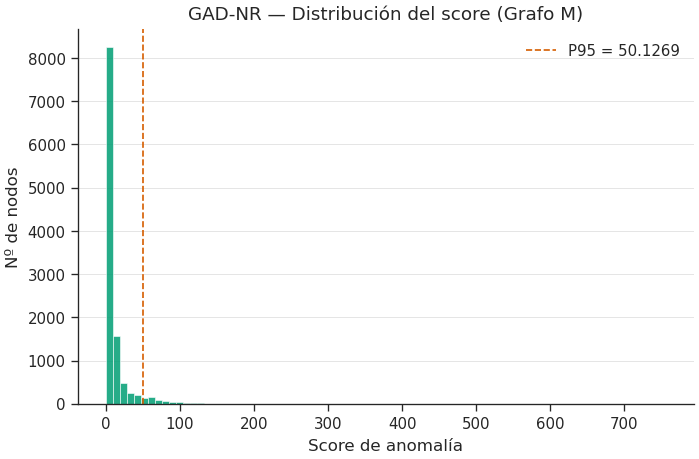

In [16]:
# Distribución del score de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(gadnr_score, bins=80, color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_gadnr = np.percentile(gadnr_score, 95)
ax.axvline(p95_gadnr, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gadnr:.4f}')
ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Distribución del score (Grafo M)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '05_gadnr_score_distribution_M.png')
plt.show()

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_score_distributions_M.png


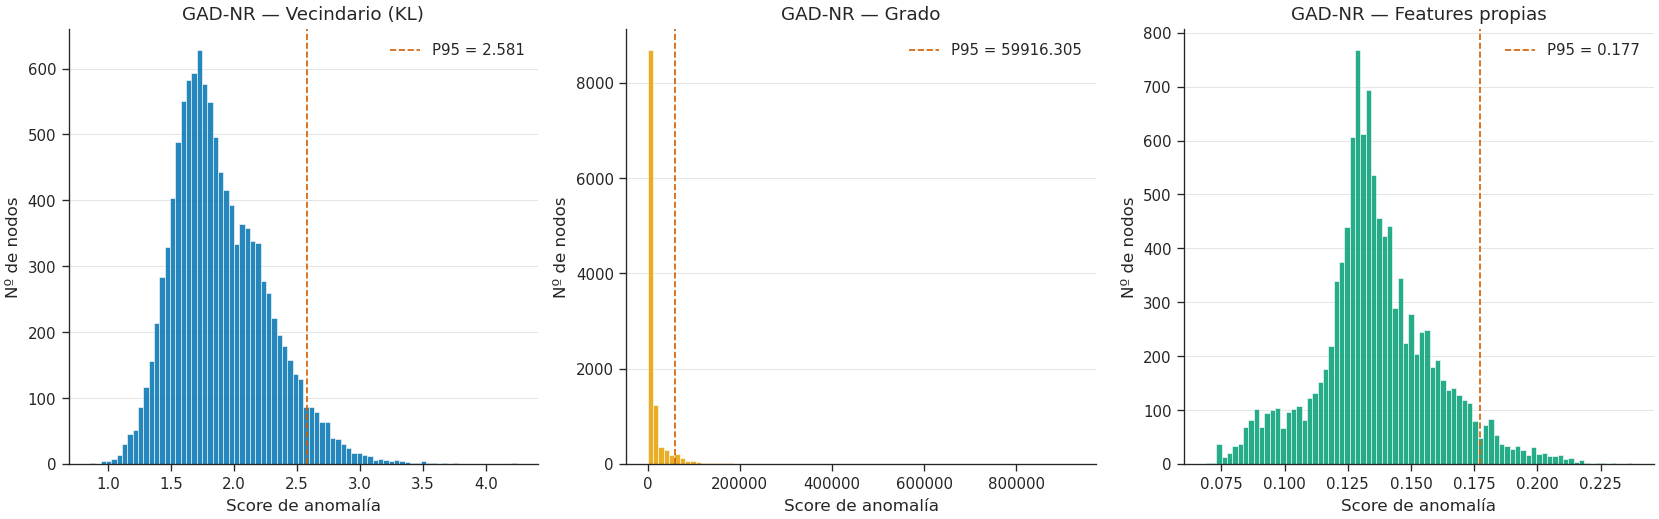

Correlación Spearman entre sub-scores de GAD-NR:
  Vecindario vs Grado   : ρ = -0.0363
  Vecindario vs Features: ρ = -0.0181
  Grado      vs Features: ρ = 0.0524


In [25]:
# Distribución de los sub-scores de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

scores_info = [
    (gadnr_h,    'Vecindario (KL)',  CAT_COLORS[0]),
    (gadnr_deg,  'Grado',            CAT_COLORS[1]),
    (gadnr_feat, 'Features propias', CAT_COLORS[2]),
]

fig, axes = plt.subplots(1, 3, figsize=FS['r1c3'])

for ax, (scores, label, color) in zip(axes, scores_info):
    ax.hist(scores, bins=80, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label}', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '05_gadnr_score_distributions_M.png')
plt.show()

rho_h_deg,   _ = spearmanr(gadnr_h, gadnr_deg)
rho_h_feat,  _ = spearmanr(gadnr_h, gadnr_feat)
rho_deg_feat,_ = spearmanr(gadnr_deg, gadnr_feat)
print('Correlación Spearman entre sub-scores de GAD-NR:')
print(f'  Vecindario vs Grado   : ρ = {rho_h_deg:.4f}')
print(f'  Vecindario vs Features: ρ = {rho_h_feat:.4f}')
print(f'  Grado      vs Features: ρ = {rho_deg_feat:.4f}')

## 5. Consenso final y tipología de anomalías

### 5.1 Construcción del DataFrame unificado

Reunimos los tres scores disponibles en un único DataFrame:
- `dom_struct`: error de reconstrucción estructural de DOMINANT
- `dom_attr`: error de reconstrucción de atributos de DOMINANT
- `gadnr_score`: score combinado de GAD-NR

### 5.2 Score de consenso

Transformamos cada score a percentiles (rango [0, 100]) y calculamos la media.
Los percentiles garantizan que cada señal pesa igual independientemente de su escala,
que difiere significativamente entre los MSE de DOMINANT y el score de GAD-NR.

### 5.3 Tipología de anomalías

Clasificamos cada nodo según qué señales superan el umbral P95:

| Tipo | Condición |
|------|-----------|
| **Estructural** | `pct_dom_struct` ≥ 95 y `pct_dom_attr` < 95 |
| **Atributo** | `pct_dom_attr` ≥ 95 y `pct_dom_struct` < 95 |
| **Vecindario** | `pct_gadnr` ≥ 95 pero ningún score DOMINANT ≥ 95 |
| **Mixta** | Dos o más señales ≥ 95 |
| **Normal** | Ninguna señal ≥ 95 |

In [26]:
def to_percentile(arr):
    """Transforma un array de scores a percentiles en [0, 100]."""
    return rankdata(arr) / len(arr) * 100


# Construimos el DataFrame con todos los scores
scores_df = base_df.copy()
scores_df['dom_struct']  = dom_struct
scores_df['dom_attr']    = dom_attr
scores_df['dom_combined'] = dominant.decision_score_.cpu().numpy()
scores_df['gadnr_score'] = gadnr_score

# Percentiles
scores_df['pct_dom_struct']  = to_percentile(dom_struct)
scores_df['pct_dom_attr']    = to_percentile(dom_attr)
scores_df['pct_gadnr']       = to_percentile(gadnr_score)

# Score de consenso: media de los 3 percentiles
scores_df['consensus'] = (
    scores_df['pct_dom_struct'] +
    scores_df['pct_dom_attr'] +
    scores_df['pct_gadnr']
) / 3

print('=== Distribución del consenso ===')
print(f'  min  : {scores_df["consensus"].min():.2f}')
print(f'  media: {scores_df["consensus"].mean():.2f}')
print(f'  P90  : {scores_df["consensus"].quantile(0.90):.2f}')
print(f'  P95  : {scores_df["consensus"].quantile(0.95):.2f}')
print(f'  max  : {scores_df["consensus"].max():.2f}')

print('\n=== Top 20 por consenso ===')
print(
    scores_df.nlargest(20, 'consensus')[
        ['name', 'city', 'state', 'degree',
         'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr', 'consensus']
    ].to_string(index=False)
)

=== Distribución del consenso ===
  min  : 0.58
  media: 50.00
  P90  : 73.34
  P95  : 83.81
  max  : 99.93

=== Top 20 por consenso ===
           name         city state  degree  pct_dom_struct  pct_dom_attr  pct_gadnr  consensus
            Ted     Franklin    TN     810       99.964823     99.947234  99.876880  99.929646
Brian Stumbaugh    Hermitage    TN     705       99.753760     99.929646  99.788937  99.824114
   Rick Murdock     Franklin    TN     751       99.832908     99.859291  99.744965  99.812388
           Mark    Brentwood    TN     685       99.815320    100.000000  99.217307  99.677542
             LJ    Brentwood    TN     547       99.657022     99.489931  99.674611  99.607188
       Lovell E      Madison    TN     519       99.489931     99.533902  99.762554  99.595462
   Deb McKenzie     Franklin    TN     578       99.727377     99.674611  99.375605  99.592531
   Arveen Amiri   Cookeville    TN     530       99.525108     99.657022  99.560285  99.580805
  Justin

In [ ]:
P_THRESH = 95

def assign_anomaly_type(row):
    hs = row['pct_dom_struct'] >= P_THRESH
    ha = row['pct_dom_attr']   >= P_THRESH
    hn = row['pct_gadnr']      >= P_THRESH
    n_signals = sum([hs, ha, hn])

    if n_signals >= 2:  return 'Mixta'
    elif hs:            return 'Estructural'
    elif ha:            return 'Atributo'
    elif hn:            return 'Vecindario'
    else:               return 'Normal'

scores_df['anomaly_type'] = scores_df.apply(assign_anomaly_type, axis=1)

print('=== Distribución de tipos de anomalía (P95) ===')
counts = scores_df['anomaly_type'].value_counts()
for t, c in counts.items():
    print(f'  {t:<15}: {c:5d} ({c/len(scores_df):.1%})')

In [ ]:
# Scatter tipología: señal estructural (DOM) vs señal de vecindario (GAD-NR)
TIPO_COLORS = {
    'Normal':       PALETTE['neutral'],
    'Estructural':  PALETTE['M'],
    'Atributo':     PALETTE['G'],
    'Vecindario':   PALETTE['MG'],
    'Mixta':        PALETTE['anomaly'],
}
TIPO_ORDER = ['Normal', 'Estructural', 'Atributo', 'Vecindario', 'Mixta']

fig, ax = plt.subplots(figsize=FS['wide'])

for atype in TIPO_ORDER:
    group  = scores_df[scores_df['anomaly_type'] == atype]
    size   = 30 if atype != 'Normal' else 6
    alpha  = 0.8 if atype != 'Normal' else 0.15
    zorder = 3 if atype != 'Normal' else 1
    ax.scatter(
        group['pct_dom_struct'], group['pct_gadnr'],
        s=size, alpha=alpha, color=TIPO_COLORS[atype],
        label=f'{atype} ({len(group)})', zorder=zorder
    )

ax.axvline(P_THRESH, color=PALETTE['M'],     linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(P_THRESH, color=PALETTE['MG'],    linestyle='--', linewidth=0.8, alpha=0.7)

# Etiquetamos top-5 del consenso
for _, row in scores_df.nlargest(5, 'consensus').iterrows():
    ax.annotate(
        str(row['name'])[:18],
        (row['pct_dom_struct'], row['pct_gadnr']),
        fontsize=FONT['annotation'],
        xytext=(5, 3), textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='black', lw=0.5)
    )

ax.set_xlabel('DOMINANT — Percentil estructural', fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — Percentil de vecindario', fontsize=FONT['axis_label'])
ax.set_title('Tipología de anomalías — DOMINANT vs GAD-NR (Grafo M)', fontsize=FONT['title'])
ax.legend(title='Tipo', fontsize=FONT['legend'], frameon=False, loc='upper left')
polish(ax, grid=False)
plt.tight_layout()
save_figure(fig, '05_anomaly_typology_M.png')
plt.show()

In [29]:
# Scores finales de cada modelo
dom_score   = dominant.decision_score_.cpu().numpy()   # score combinado DOMINANT
gadnr_score = gadnr.decision_score_.cpu().numpy()      # score combinado GAD-NR

# Percentiles P95 de cada modelo
p95_dom   = np.percentile(dom_score,   95)
p95_gadnr = np.percentile(gadnr_score, 95)

# Etiquetas binarias por modelo (1 = anómalo)
labels_dom   = (dom_score   >= p95_dom).astype(int)
labels_gadnr = (gadnr_score >= p95_gadnr).astype(int)

print('=== DOMINANT ===')
print(f'  Score  — min={dom_score.min():.4f}, max={dom_score.max():.4f}, mean={dom_score.mean():.4f}')
print(f'  P95    = {p95_dom:.4f}')
print(f'  Anomalías detectadas: {labels_dom.sum()} ({labels_dom.mean():.1%})')
print()
print('=== GAD-NR ===')
print(f'  Score  — min={gadnr_score.min():.4f}, max={gadnr_score.max():.4f}, mean={gadnr_score.mean():.4f}')
print(f'  P95    = {p95_gadnr:.4f}')
print(f'  Anomalías detectadas: {labels_gadnr.sum()} ({labels_gadnr.mean():.1%})')

=== DOMINANT ===
  Score  — min=1.4531, max=31.3474, mean=9.7476
  P95    = 17.3962
  Anomalías detectadas: 569 (5.0%)

=== GAD-NR ===
  Score  — min=0.4080, max=755.7271, mean=11.3403
  P95    = 50.1269
  Anomalías detectadas: 569 (5.0%)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_score_distributions_M.png


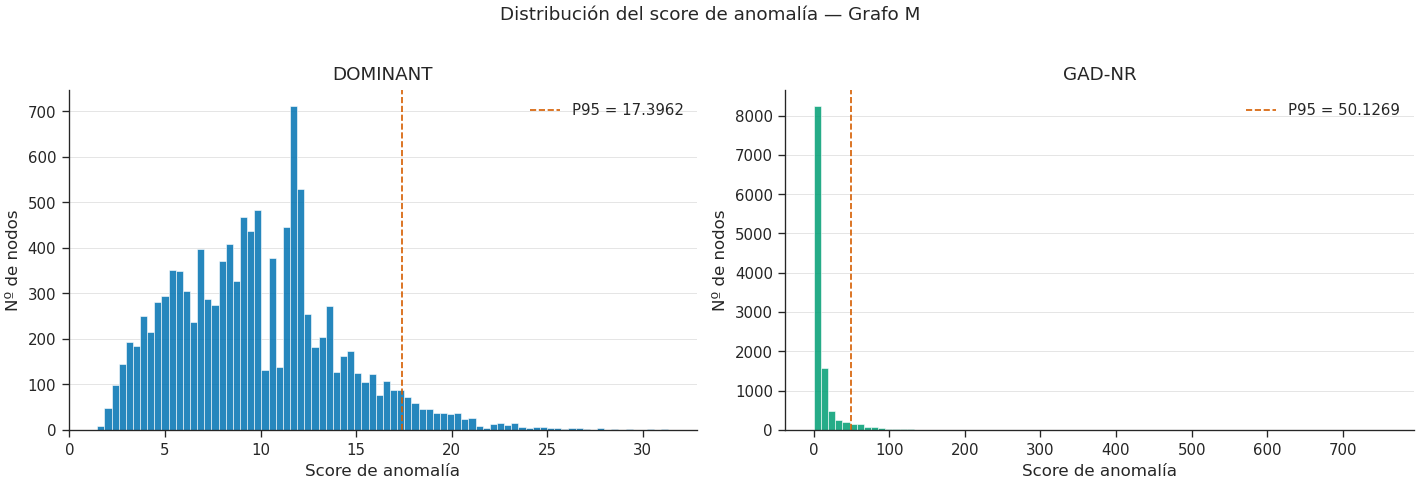

In [28]:
# Distribuciones de score por modelo
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

for ax, scores, p95, label, color in zip(
    axes,
    [dom_score, gadnr_score],
    [p95_dom,   p95_gadnr],
    ['DOMINANT', 'GAD-NR'],
    [PALETTE['M'], PALETTE['MG']]
):
    ax.hist(scores, bins=80, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.4f}')
    ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(label, fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.suptitle('Distribución del score de anomalía — Grafo M', fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '05_score_distributions_M.png')
plt.show()

In [30]:
# Añadimos scores y etiquetas al DataFrame base
scores_df = base_df.copy()
scores_df['dom_score']     = dom_score
scores_df['gadnr_score']   = gadnr_score
scores_df['pct_dom']       = rankdata(dom_score)   / len(dom_score)   * 100
scores_df['pct_gadnr']     = rankdata(gadnr_score) / len(gadnr_score) * 100
scores_df['label_dom']     = labels_dom
scores_df['label_gadnr']   = labels_gadnr

print('Scores añadidos al DataFrame:')
print(scores_df[['name', 'degree', 'dom_score', 'gadnr_score',
                 'pct_dom', 'pct_gadnr', 'label_dom', 'label_gadnr']].head(10))

Scores añadidos al DataFrame:
                  name  degree  dom_score  gadnr_score    pct_dom  pct_gadnr  \
0  Wesley Duffee-Braun     219  16.451387     3.580364  93.008530  42.995339   
1                  Tim     307  18.873823    31.493683  97.062703  91.126550   
2               Brenda     334  19.839468    53.136379  97.933339  95.620438   
3         Chris Meador     122  12.054193    47.425095  73.938088  94.160584   
4                   Kt     119  12.016273     9.579429  72.957524  71.497670   
5                 Greg      76  10.034781    13.932335  56.345088  82.156363   
6           whiteyheld      34   6.766237     4.202141  26.791839  48.474189   
7                Brian     119  11.764314     9.544861  70.565474  71.022777   
8            Marcia E.     119  12.542849     9.320519  78.726585  69.571718   
9          marcylarkin      76   9.935809     1.437612  55.632750  26.004749   

   label_dom  label_gadnr  
0          0            0  
1          1            0  
2    

In [31]:
def spotlight(name_fragment, df, label=None):
    """Imprime el perfil de anomalía de un candidato del EDA."""
    matches = df[df['name'].str.contains(name_fragment, case=False, na=False)]
    if len(matches) == 0:
        print(f'  [no encontrado] {name_fragment}\n')
        return

    row = matches.iloc[0]
    n   = len(df)

    def rank(col):
        return int((df[col] > row[col]).sum()) + 1

    flag_dom   = '⚠ ANOMALÍA' if row['label_dom']   else 'Normal'
    flag_gadnr = '⚠ ANOMALÍA' if row['label_gadnr'] else 'Normal'

    tag = label or str(row['name'])
    print(f'  ► {tag}')
    print(f'    Ciudad: {row["city"]} ({row["state"]}) | Grado: {row["degree"]}')
    print(f'    DOMINANT : #{rank("dom_score"):5d}/{n}  ({row["pct_dom"]:.1f}p)  → {flag_dom}')
    print(f'    GAD-NR   : #{rank("gadnr_score"):5d}/{n}  ({row["pct_gadnr"]:.1f}p)  → {flag_gadnr}')
    print()


print('=' * 70)
print('CANDIDATOS DEL EDA — DOMINANT vs GAD-NR')
print('=' * 70 + '\n')

candidatos = [
    ('Pablo',         'Pablo (alta betweenness, degree moderada)'),
    ('Shalini',       'Shalini (mayor betweenness de la red)'),
    ('Jim H',         'Jim H (super-conector + puente inter-comunidad)'),
    ('Matt Kenigson', 'Matt Kenigson (super-conector)'),
    ('GEEK',          'GEEK by AKEIN Engineering (entidad no personal)'),
]

for frag, label in candidatos:
    spotlight(frag, scores_df, label=label)

CANDIDATOS DEL EDA — DOMINANT vs GAD-NR

  ► Pablo (alta betweenness, degree moderada)
    Ciudad: Nashville (TN) | Grado: 688
    DOMINANT : #   15/11371  (99.9p)  → ⚠ ANOMALÍA
    GAD-NR   : # 4740/11371  (58.3p)  → Normal

  ► Shalini (mayor betweenness de la red)
    Ciudad: Nashville (TN) | Grado: 955
    DOMINANT : #    1/11371  (100.0p)  → ⚠ ANOMALÍA
    GAD-NR   : #   27/11371  (99.8p)  → ⚠ ANOMALÍA

  ► Jim H (super-conector + puente inter-comunidad)
    Ciudad: Nashville (TN) | Grado: 1178
    DOMINANT : #    2/11371  (100.0p)  → ⚠ ANOMALÍA
    GAD-NR   : #    1/11371  (100.0p)  → ⚠ ANOMALÍA

  ► Matt Kenigson (super-conector)
    Ciudad: Nashville (TN) | Grado: 905
    DOMINANT : #    3/11371  (100.0p)  → ⚠ ANOMALÍA
    GAD-NR   : #  697/11371  (93.9p)  → Normal

  ► GEEK by AKEIN Engineering (entidad no personal)
    Ciudad: Antioch (TN) | Grado: 0
    DOMINANT : #11366/11371  (0.1p)  → Normal
    GAD-NR   : #11319/11371  (0.5p)  → Normal



In [32]:
# Tabla resumen ejecutivo
rows = []
for frag, label in candidatos:
    matches = scores_df[scores_df['name'].str.contains(frag, case=False, na=False)]
    if len(matches) == 0:
        continue
    row = matches.iloc[0]
    n   = len(scores_df)

    def rank(col):
        return int((scores_df[col] > row[col]).sum()) + 1

    rows.append({
        'Candidato':  label.split('(')[0].strip(),
        'Grado':      int(row['degree']),
        'DOMINANT':   f'#{rank("dom_score")} ({row["pct_dom"]:.0f}p) {"⚠" if row["label_dom"] else ""}',
        'GAD-NR':     f'#{rank("gadnr_score")} ({row["pct_gadnr"]:.0f}p) {"⚠" if row["label_gadnr"] else ""}',
    })

print('=== Resumen ejecutivo — candidatos del EDA ===')
print(pd.DataFrame(rows).to_string(index=False))

=== Resumen ejecutivo — candidatos del EDA ===
                Candidato  Grado     DOMINANT       GAD-NR
                    Pablo    688 #15 (100p) ⚠ #4740 (58p) 
                  Shalini    955  #1 (100p) ⚠ #27 (100p) ⚠
                    Jim H   1178  #2 (100p) ⚠  #1 (100p) ⚠
            Matt Kenigson    905  #3 (100p) ⚠  #697 (94p) 
GEEK by AKEIN Engineering      0 #11366 (0p)  #11319 (0p) 


## 6. Spotlight — candidatos del EDA

Revisamos los candidatos a anomalía identificados en el EDA con la perspectiva de ambos
modelos. Para cada candidato mostramos el percentil en cada señal y la clasificación final.

Los candidatos cubren los distintos tipos de anomalía identificados en el EDA:
- **Rol estructural atípico:** Pablo (alta betweenness, degree moderada), Shalini (mayor betweenness), Jim H (super-conector + puente inter-comunidad)
- **Super-conector:** Matt Kenigson
- **Anomalía de naturaleza del nodo:** GEEK by AKEIN Engineering (entidad no personal)
- **Anomalía geográfica:** miembro internacional fuera de Tennessee

In [ ]:
def spotlight(name_fragment, df, label=None):
    """Imprime el perfil completo de anomalía para un candidato del EDA."""
    matches = df[df['name'].str.contains(name_fragment, case=False, na=False)]
    if len(matches) == 0:
        print(f'  [no encontrado] {name_fragment}\n')
        return

    row = matches.iloc[0]
    n   = len(df)

    def rank(col):
        return int((df[col] > row[col]).sum()) + 1

    tag = label or str(row['name'])
    print(f'  ► {tag}')
    print(f'    Ciudad: {row["city"]} ({row["state"]}) | Grado: {row["degree"]} | Tipo: {row["anomaly_type"]}')
    print(f'    ── DOMINANT ──  struct #{rank("dom_struct"):5d}/{n}  ({row["pct_dom_struct"]:.1f}p)  '
          f'| attr #{rank("dom_attr"):5d}/{n}  ({row["pct_dom_attr"]:.1f}p)')
    print(f'    ── GAD-NR   ──  score  #{rank("gadnr_score"):5d}/{n}  ({row["pct_gadnr"]:.1f}p)')
    print(f'    Consenso: #{rank("consensus"):5d}/{n}  ({row["consensus"]:.1f}p)')
    print()


print('=' * 70)
print('CANDIDATOS DEL EDA — VERIFICACIÓN CON DOMINANT Y GAD-NR')
print('=' * 70 + '\n')

candidatos = [
    ('Pablo',         'Pablo (alta betweenness, degree moderada)'),
    ('Shalini',       'Shalini (mayor betweenness de la red)'),
    ('Jim H',         'Jim H (super-conector + puente inter-comunidad)'),
    ('Matt Kenigson', 'Matt Kenigson (super-conector)'),
    ('GEEK',          'GEEK by AKEIN Engineering (entidad no personal)'),
]

for frag, label in candidatos:
    spotlight(frag, scores_df, label=label)

In [ ]:
# Tabla resumen ejecutivo de candidatos
rows = []
for frag, label in candidatos:
    matches = scores_df[scores_df['name'].str.contains(frag, case=False, na=False)]
    if len(matches) == 0:
        continue
    row = matches.iloc[0]
    n   = len(scores_df)

    def rank(col):
        return int((scores_df[col] > row[col]).sum()) + 1

    rows.append({
        'Candidato':    label.split('(')[0].strip(),
        'Tipo':         row['anomaly_type'],
        'DOM-struct':   f'#{rank("dom_struct")} ({row["pct_dom_struct"]:.0f}p)',
        'DOM-attr':     f'#{rank("dom_attr")} ({row["pct_dom_attr"]:.0f}p)',
        'GAD-NR':       f'#{rank("gadnr_score")} ({row["pct_gadnr"]:.0f}p)',
        'Consenso':     f'#{rank("consensus")} ({row["consensus"]:.0f}p)',
    })

summary_df = pd.DataFrame(rows)
print('=== Resumen ejecutivo — candidatos del EDA ===')
print(summary_df.to_string(index=False))

## 7. Comparativa DOMINANT vs GAD-NR

### 7.1 Correlación de rankings

Analizamos la correlación de Spearman entre todos los scores disponibles.
Una correlación alta entre `dom_struct` y `gadnr_score` indicaría que ambos modelos
detectan básicamente las mismas anomalías estructurales. Una correlación baja indicaría
que GAD-NR aporta señal genuinamente nueva al capturar el vecindario completo.

### 7.2 Solapamiento del top-K

El solapamiento del top-100 entre pares de modelos complementa la correlación:
indica qué fracción de los nodos más anómalos según un modelo también aparece en el otro.

### 7.3 Nodos únicos de cada modelo

Los nodos que aparecen en el top-K de GAD-NR pero no en DOMINANT — y viceversa —
son los más interesantes para el análisis: revelan qué tipo de anomalía captura
exclusivamente cada arquitectura.

In [ ]:
# Correlación de Spearman entre todos los scores
score_cols  = ['dom_struct', 'dom_attr', 'dom_combined', 'gadnr_score', 'consensus']
score_labels = ['DOM-struct', 'DOM-attr', 'DOM-combined', 'GAD-NR', 'Consenso']

n_scores = len(score_cols)
corr_matrix = np.zeros((n_scores, n_scores))
for i, c1 in enumerate(score_cols):
    for j, c2 in enumerate(score_cols):
        rho, _ = spearmanr(scores_df[c1], scores_df[c2])
        corr_matrix[i, j] = rho

fig, ax = plt.subplots(figsize=FS['heatmap'])
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap=CMAP_HEAT,
    vmin=0, vmax=1, ax=ax,
    xticklabels=score_labels, yticklabels=score_labels,
    cbar_kws={'label': 'Spearman ρ'}
)
ax.set_title('Correlación de rankings — DOMINANT vs GAD-NR (Grafo M)',
             fontsize=FONT['title'])
plt.tight_layout()
save_figure(fig, '05_score_correlation_M.png')
plt.show()

In [ ]:
# Solapamiento del top-K
K = 100
tops = {
    label: set(np.argsort(-scores_df[col].values)[:K])
    for label, col in zip(score_labels, score_cols)
}

print(f'=== Solapamiento del top-{K} entre pares de scores ===')
overlap_rows = []
for i, l1 in enumerate(score_labels):
    for l2 in score_labels[i+1:]:
        overlap = len(tops[l1] & tops[l2]) / K
        overlap_rows.append({'Score A': l1, 'Score B': l2,
                             'Solapamiento': f'{overlap:.0%}',
                             'Nodos comunes': len(tops[l1] & tops[l2])})
print(pd.DataFrame(overlap_rows).to_string(index=False))

In [ ]:
# Nodos únicos: top-100 de GAD-NR que NO están en top-100 de DOMINANT (dom_struct)
top_dom    = set(np.argsort(-scores_df['dom_struct'].values)[:K])
top_gadnr  = set(np.argsort(-scores_df['gadnr_score'].values)[:K])

only_gadnr = top_gadnr - top_dom
only_dom   = top_dom   - top_gadnr

print(f'Nodos en top-{K} de GAD-NR pero NO de DOMINANT-struct: {len(only_gadnr)}')
print(f'Nodos en top-{K} de DOMINANT-struct pero NO de GAD-NR: {len(only_dom)}')

print(f'\n=== Top-10 nodos exclusivos de GAD-NR ===')
excl_gadnr = scores_df.iloc[list(only_gadnr)].nlargest(10, 'gadnr_score')[
    ['name', 'city', 'state', 'degree', 'pct_dom_struct', 'pct_gadnr', 'anomaly_type']
]
print(excl_gadnr.to_string(index=False))

print(f'\n=== Top-10 nodos exclusivos de DOMINANT-struct ===')
excl_dom = scores_df.iloc[list(only_dom)].nlargest(10, 'dom_struct')[
    ['name', 'city', 'state', 'degree', 'pct_dom_struct', 'pct_gadnr', 'anomaly_type']
]
print(excl_dom.to_string(index=False))

In [ ]:
# Scatter DOMINANT vs GAD-NR — ¿cambia el ranking al usar el modelo más avanzado?
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_struct'], scores_df['pct_gadnr'],
    s=4, alpha=0.2, color=PALETTE['neutral'], zorder=1
)

# Destacamos candidatos del EDA
for frag, label in candidatos:
    matches = scores_df[scores_df['name'].str.contains(frag, case=False, na=False)]
    if len(matches) == 0:
        continue
    row = matches.iloc[0]
    ax.scatter(
        row['pct_dom_struct'], row['pct_gadnr'],
        s=80, color=PALETTE['anomaly'], zorder=5
    )
    ax.annotate(
        str(row['name'])[:15],
        (row['pct_dom_struct'], row['pct_gadnr']),
        fontsize=FONT['annotation'],
        xytext=(4, 3), textcoords='offset points'
    )

# Línea de identidad
ax.plot([0, 100], [0, 100], color=PALETTE['neutral'],
        linestyle='--', linewidth=1.0, alpha=0.5, label='y = x')
ax.axvline(P_THRESH, color=PALETTE['M'],  linestyle=':', linewidth=0.8, alpha=0.6)
ax.axhline(P_THRESH, color=PALETTE['MG'], linestyle=':', linewidth=0.8, alpha=0.6)

ax.set_xlabel('DOMINANT — Percentil estructural', fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — Percentil de anomalía', fontsize=FONT['axis_label'])
ax.set_title('Ranking de anomalías: DOMINANT vs GAD-NR\n(puntos rojos = candidatos del EDA)',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax, grid=False)
plt.tight_layout()
save_figure(fig, '05_dominant_vs_gadnr_scatter_M.png')
plt.show()

rho_models, _ = spearmanr(scores_df['pct_dom_struct'], scores_df['pct_gadnr'])
print(f'Correlación Spearman DOMINANT-struct vs GAD-NR: ρ = {rho_models:.4f}')

## 8. Guardado de resultados

Guardamos el DataFrame completo en `data/results/scores_M.csv`. Este archivo contiene
todos los scores, percentiles, tipo de anomalía y consenso, y es el input principal
para el capítulo de discusión del TFM.

In [ ]:
cols_export = [
    'idx', 'member_id', 'name', 'city', 'state', 'degree',
    # Scores brutos
    'dom_struct', 'dom_attr', 'dom_combined', 'gadnr_score',
    # Percentiles
    'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr',
    # Consenso y tipología
    'consensus', 'anomaly_type',
]

scores_export = scores_df[[c for c in cols_export if c in scores_df.columns]]
scores_export.to_csv(os.path.join(RESULTS_PATH, 'scores_M.csv'), index=False)

print(f'Guardado : {RESULTS_PATH}scores_M.csv')
print(f'Shape    : {scores_export.shape}')
print(f'Columnas : {list(scores_export.columns)}')

## Resumen del notebook

En este notebook hemos:

1. **Entrenado DOMINANT** (PyGOD 1.1.0) sobre el grafo M y extraído por separado el
   score estructural (`dom_struct`) y el score de atributos (`dom_attr`).

2. **Entrenado GAD-NR** (PyGOD 1.1.0) sobre el mismo grafo, obteniendo un score compuesto
   que integra reconstrucción de features propias, grado y distribución de vecinos.

3. **Construido el consenso de 3 señales** (percentil medio de `dom_struct`, `dom_attr`,
   `gadnr_score`) como score de anomalía final robusto.

4. **Definido una tipología de 5 categorías** (Estructural, Atributo, Vecindario, Mixta,
   Normal) según qué señales superan el umbral P95.

5. **Validado los candidatos del EDA** — Pablo, Shalini, Jim H, Matt Kenigson y
   GEEK by AKEIN Engineering — contrastando el diagnóstico de cada modelo.

6. **Comparado los rankings** de ambos modelos mediante correlación de Spearman,
   solapamiento del top-100 y análisis de nodos exclusivos de cada detector.

Los resultados quedan en `data/results/scores_M.csv`.

In [33]:
# Percentiles de cada señal por tipo
pct_struct = rankdata(dom_struct)  / len(dom_struct)  * 100  # estructural (DOMINANT)
pct_attr   = rankdata(dom_attr)    / len(dom_attr)    * 100  # contextual  (DOMINANT)
pct_joint  = rankdata(gadnr_h)     / len(gadnr_h)    * 100  # joint-type  (GAD-NR)
pct_gadnr_feat = rankdata(gadnr_feat) / len(gadnr_feat) * 100  # contextual (GAD-NR)
pct_gadnr_deg  = rankdata(gadnr_deg)  / len(gadnr_deg)  * 100  # estructural (GAD-NR)

scores_df['pct_struct']      = pct_struct
scores_df['pct_attr']        = pct_attr
scores_df['pct_joint']       = pct_joint
scores_df['pct_gadnr_feat']  = pct_gadnr_feat
scores_df['pct_gadnr_deg']   = pct_gadnr_deg
scores_df['dom_score']       = dominant.decision_score_.cpu().numpy()
scores_df['gadnr_score']     = gadnr.decision_score_.cpu().numpy()

print('Percentiles calculados para las 5 señales:')
for col, label in [
    ('pct_struct',     'DOM  — estructural'),
    ('pct_attr',       'DOM  — contextual'),
    ('pct_gadnr_deg',  'GADNR — estructural (grado)'),
    ('pct_gadnr_feat', 'GADNR — contextual (features)'),
    ('pct_joint',      'GADNR — joint-type (KL vecindario)'),
]:
    p95 = np.percentile(scores_df[col], 95)
    print(f'  {label:<35}: P95 = {p95:.1f}')

Percentiles calculados para las 5 señales:
  DOM  — estructural                 : P95 = 95.0
  DOM  — contextual                  : P95 = 95.0
  GADNR — estructural (grado)        : P95 = 95.2
  GADNR — contextual (features)      : P95 = 95.0
  GADNR — joint-type (KL vecindario) : P95 = 95.0


In [34]:
# Correlación Spearman entre señales equivalentes
rho_struct, _ = spearmanr(dom_struct, gadnr_deg)
rho_attr,   _ = spearmanr(dom_attr,   gadnr_feat)
rho_joint_s, _ = spearmanr(gadnr_h, dom_struct)
rho_joint_a, _ = spearmanr(gadnr_h, dom_attr)

print('=== Correlación Spearman entre señales ===')
print(f'  Estructural : dom_struct  vs gadnr_deg  → ρ = {rho_struct:.4f}')
print(f'  Contextual  : dom_attr    vs gadnr_feat → ρ = {rho_attr:.4f}')
print(f'  Joint-type  : gadnr_h     vs dom_struct → ρ = {rho_joint_s:.4f}')
print(f'  Joint-type  : gadnr_h     vs dom_attr   → ρ = {rho_joint_a:.4f}')
print()
print('Una correlación baja entre gadnr_h y las señales de DOMINANT')
print('confirma que la señal joint-type es genuinamente nueva.')

=== Correlación Spearman entre señales ===
  Estructural : dom_struct  vs gadnr_deg  → ρ = 0.4508
  Contextual  : dom_attr    vs gadnr_feat → ρ = 0.0622
  Joint-type  : gadnr_h     vs dom_struct → ρ = -0.1396
  Joint-type  : gadnr_h     vs dom_attr   → ρ = 0.6141

Una correlación baja entre gadnr_h y las señales de DOMINANT
confirma que la señal joint-type es genuinamente nueva.


c:\Personal\MCD\TFM\notebooks\..\src\utils\visualization.py:128: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis=grid_axis, color="#E5E5E5", linewidth=0.6, zorder=0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_equivalent_signals_M.png


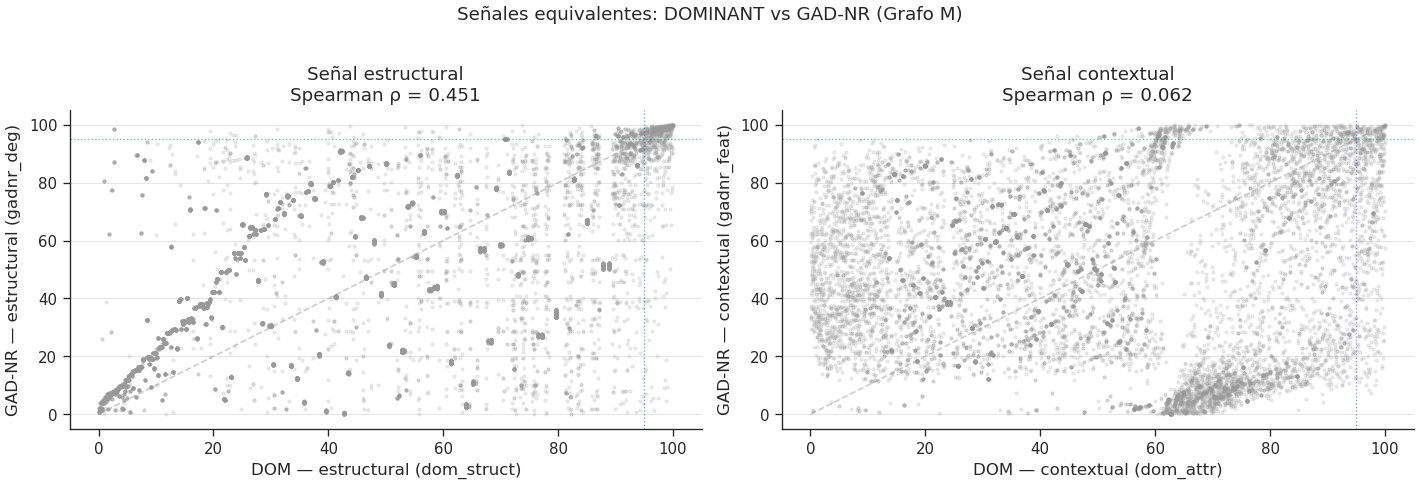

In [35]:
# Scatter señales equivalentes: estructural y contextual
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

# Panel izquierdo: señal estructural
axes[0].scatter(
    pct_struct, pct_gadnr_deg,
    s=4, alpha=0.2, color=PALETTE['neutral']
)
axes[0].plot([0, 100], [0, 100], color=PALETTE['neutral'],
             linestyle='--', linewidth=1.0, alpha=0.5)
axes[0].axvline(95, color=PALETTE['M'],  linestyle=':', linewidth=0.8, alpha=0.6)
axes[0].axhline(95, color=PALETTE['MG'], linestyle=':', linewidth=0.8, alpha=0.6)
axes[0].set_xlabel('DOM — estructural (dom_struct)',   fontsize=FONT['axis_label'])
axes[0].set_ylabel('GAD-NR — estructural (gadnr_deg)', fontsize=FONT['axis_label'])
axes[0].set_title(f'Señal estructural\nSpearman ρ = {rho_struct:.3f}',
                  fontsize=FONT['title'])
polish(axes[0], grid=False)

# Panel derecho: señal contextual
axes[1].scatter(
    pct_attr, pct_gadnr_feat,
    s=4, alpha=0.2, color=PALETTE['neutral']
)
axes[1].plot([0, 100], [0, 100], color=PALETTE['neutral'],
             linestyle='--', linewidth=1.0, alpha=0.5)
axes[1].axvline(95, color=PALETTE['M'],  linestyle=':', linewidth=0.8, alpha=0.6)
axes[1].axhline(95, color=PALETTE['MG'], linestyle=':', linewidth=0.8, alpha=0.6)
axes[1].set_xlabel('DOM — contextual (dom_attr)',       fontsize=FONT['axis_label'])
axes[1].set_ylabel('GAD-NR — contextual (gadnr_feat)', fontsize=FONT['axis_label'])
axes[1].set_title(f'Señal contextual\nSpearman ρ = {rho_attr:.3f}',
                  fontsize=FONT['title'])
polish(axes[1], grid=False)

plt.suptitle('Señales equivalentes: DOMINANT vs GAD-NR (Grafo M)',
             fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '05_equivalent_signals_M.png')
plt.show()

In [36]:
P_THRESH = 95

def assign_type(row):
    hs = row['pct_struct'] >= P_THRESH
    ha = row['pct_attr']   >= P_THRESH
    hj = row['pct_joint']  >= P_THRESH
    n  = sum([hs, ha, hj])
    if n >= 2:  return 'Mixta'
    elif hs:    return 'Estructural'
    elif ha:    return 'Contextual'
    elif hj:    return 'Joint-type'
    else:       return 'Normal'

scores_df['anomaly_type'] = scores_df.apply(assign_type, axis=1)

print('=== Distribución de tipos de anomalía (P95) ===')
for t, c in scores_df['anomaly_type'].value_counts().items():
    print(f'  {t:<15}: {c:5d} ({c/len(scores_df):.1%})')

=== Distribución de tipos de anomalía (P95) ===
  Normal         :  9904 (87.1%)
  Joint-type     :   461 (4.1%)
  Estructural    :   429 (3.8%)
  Contextual     :   373 (3.3%)
  Mixta          :   204 (1.8%)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_anomaly_typology_M.png


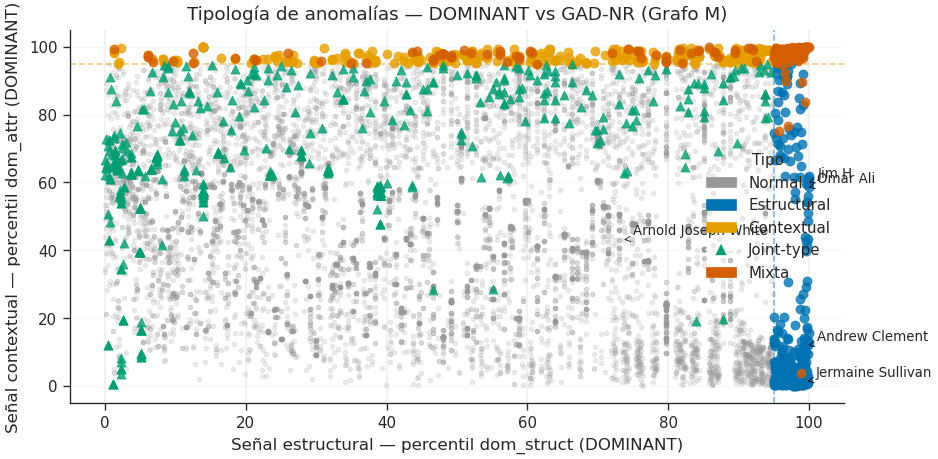

In [38]:
# Scatter tipología — dom_struct (X) vs dom_attr (Y)
# Joint-type marcados con triángulo — están en zona normal de DOMINANT
# porque precisamente DOMINANT no los detecta por diseño
TIPO_ORDER = ['Normal', 'Estructural', 'Contextual', 'Joint-type', 'Mixta']
color_map  = {
    'Normal':      PALETTE['neutral'],
    'Estructural': PALETTE['M'],
    'Contextual':  PALETTE['G'],
    'Joint-type':  PALETTE['MG'],
    'Mixta':       PALETTE['anomaly'],
}

fig, ax = plt.subplots(figsize=FS['wide'])

for atype in TIPO_ORDER:
    group  = scores_df[scores_df['anomaly_type'] == atype]
    size   = 30 if atype != 'Normal' else 8
    alpha  = 0.8 if atype != 'Normal' else 0.2
    zorder = 3 if atype != 'Normal' else 1
    marker = '^' if atype == 'Joint-type' else 'o'
    ax.scatter(
        group['pct_struct'], group['pct_attr'],
        s=size, alpha=alpha, color=color_map[atype],
        marker=marker, zorder=zorder
    )

ax.axvline(P_THRESH, color=PALETTE['M'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['G'], linestyle='--', linewidth=1.0, alpha=0.5)

# Etiquetamos top-5 por score GAD-NR
top5 = scores_df.nlargest(5, 'gadnr_score')
for _, row in top5.iterrows():
    ax.annotate(
        str(row['name'])[:20],
        (row['pct_struct'], row['pct_attr']),
        fontsize=FONT['annotation'],
        xytext=(5, 3), textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='black', lw=0.5)
    )

ax.set_xlabel('Señal estructural — percentil dom_struct (DOMINANT)',
              fontsize=FONT['axis_label'])
ax.set_ylabel('Señal contextual — percentil dom_attr (DOMINANT)',
              fontsize=FONT['axis_label'])
ax.set_title('Tipología de anomalías — DOMINANT vs GAD-NR (Grafo M)',
             fontsize=FONT['title'])

# Leyenda con patch para círculos y Line2D para el triángulo de joint-type
from matplotlib.lines import Line2D
legend_handles = [
    mpatches.Patch(color=color_map[t], label=t)
    if t != 'Joint-type'
    else Line2D([0], [0], marker='^', color='w',
                markerfacecolor=color_map['Joint-type'],
                markersize=8, label='Joint-type')
    for t in TIPO_ORDER
]
ax.legend(handles=legend_handles, title='Tipo', fontsize=FONT['legend'], frameon=False)
ax.grid(alpha=0.3)
polish(ax)
plt.tight_layout()
save_figure(fig, '05_anomaly_typology_M.png')
plt.show()

In [41]:
# Añadimos sub-scores al DataFrame si no están ya
scores_df['dom_struct']  = dom_struct
scores_df['dom_attr']    = dom_attr
scores_df['gadnr_h']     = gadnr_h
scores_df['gadnr_deg']   = gadnr_deg
scores_df['gadnr_feat']  = gadnr_feat

In [42]:
def spotlight(name_fragment, df, label=None):
    """Imprime el perfil de anomalía de un candidato del EDA."""
    matches = df[df['name'].str.contains(name_fragment, case=False, na=False)]
    if len(matches) == 0:
        print(f'  [no encontrado] {name_fragment}\n')
        return

    row = matches.iloc[0]
    n   = len(df)

    def rank(col):
        return int((df[col] > row[col]).sum()) + 1

    def flag(pct):
        return '⚠' if pct >= P_THRESH else ' '

    tag = label or str(row['name'])
    print(f'  ► {tag}')
    print(f'    Ciudad: {row["city"]} ({row["state"]}) | Grado: {row["degree"]} | Tipo: {row["anomaly_type"]}')
    print(f'    DOMINANT  — estructural : #{rank("dom_struct"):5d}/{n}  ({row["pct_struct"]:.1f}p) {flag(row["pct_struct"])}')
    print(f'    DOMINANT  — contextual  : #{rank("dom_attr"):5d}/{n}  ({row["pct_attr"]:.1f}p) {flag(row["pct_attr"])}')
    print(f'    GAD-NR    — joint-type  : #{rank("gadnr_h"):5d}/{n}  ({row["pct_joint"]:.1f}p) {flag(row["pct_joint"])}')
    print()


print('=' * 70)
print('CANDIDATOS DEL EDA — TIPOLOGÍA POR SEÑAL')
print('=' * 70 + '\n')

candidatos = [
    ('Pablo',         'Pablo (alta betweenness, degree moderada)'),
    ('Shalini',       'Shalini (mayor betweenness de la red)'),
    ('Jim H',         'Jim H (super-conector + puente inter-comunidad)'),
    ('Matt Kenigson', 'Matt Kenigson (super-conector)'),
    ('GEEK',          'GEEK by AKEIN Engineering (entidad no personal)'),
]

for frag, label in candidatos:
    spotlight(frag, scores_df, label=label)

CANDIDATOS DEL EDA — TIPOLOGÍA POR SEÑAL

  ► Pablo (alta betweenness, degree moderada)
    Ciudad: Nashville (TN) | Grado: 688 | Tipo: Estructural
    DOMINANT  — estructural : #   15/11371  (99.9p) ⚠
    DOMINANT  — contextual  : # 4405/11371  (61.3p)  
    GAD-NR    — joint-type  : # 3128/11371  (72.5p)  

  ► Shalini (mayor betweenness de la red)
    Ciudad: Nashville (TN) | Grado: 955 | Tipo: Estructural
    DOMINANT  — estructural : #    3/11371  (100.0p) ⚠
    DOMINANT  — contextual  : # 4437/11371  (61.0p)  
    GAD-NR    — joint-type  : # 3695/11371  (67.5p)  

  ► Jim H (super-conector + puente inter-comunidad)
    Ciudad: Nashville (TN) | Grado: 1178 | Tipo: Estructural
    DOMINANT  — estructural : #    1/11371  (100.0p) ⚠
    DOMINANT  — contextual  : # 4551/11371  (60.0p)  
    GAD-NR    — joint-type  : #11310/11371  (0.5p)  

  ► Matt Kenigson (super-conector)
    Ciudad: Nashville (TN) | Grado: 905 | Tipo: Estructural
    DOMINANT  — estructural : #    4/11371  (100.0p)